# NBA Triple-Double Project

Carlo Uy

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
df = pd.read_csv("data/traditional.csv", encoding = 'utf-8')

df = df[df["season"] >= 2015]
df.columns

Index(['gameid', 'date', 'type', 'playerid', 'player', 'team', 'home', 'away',
       'MIN', 'PTS', 'FGM', 'FGA', 'FG%', '3PM', '3PA', '3P%', 'FTM', 'FTA',
       'FT%', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', '+/-',
       'win', 'season'],
      dtype='object')

### Data Cleaning + Feature Engineering

In [2]:
# Necessary columns
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(by = ["playerid", "date"])

def triple_double(row):
    stats = [
        row["PTS"], row["REB"], row["AST"],
        row["STL"], row["BLK"]
    ]

    return int(sum(s >= 10 for s in stats) >= 3)



df = df.drop(columns = ["+/-", "gameid", "player", "win"])

df["TRIPLE-DOUBLE"] = df.apply(triple_double, axis = 1)

df["OPPONENT"] = df.apply(
    lambda row: row["away"] if row["team"] == row["home"] else row["home"],
    axis=1
)

df = pd.get_dummies(df, columns=["OPPONENT", "type"], prefix=["OPP", "TYPE"], drop_first=True)

df["HOME"] = (df["team"] == df["home"]).astype(int)

df = df.drop(columns = "home")
df.columns = df.columns.str.upper()


In [3]:
# Rolling averages
stats_to_roll = ["PTS", "REB", "AST", "STL", "BLK", "MIN"]

for stat in stats_to_roll:
    df[f"{stat}_AVG_LAST5"] = (
        df.groupby("PLAYERID")[stat]
        .rolling(5)
        .mean()
        .shift(1)
        .reset_index(level=0, drop=True)
    )

df = df.dropna()

feature_cols = [
    "PTS_AVG_LAST5", "REB_AVG_LAST5", "AST_AVG_LAST5",
    "STL_AVG_LAST5", "BLK_AVG_LAST5", "MIN_AVG_LAST5",
    "HOME"
]

# Only include TYPE columns IF they exist
for col in ["TYPE_PLAYIN", "TYPE_PLAYOFF", "TYPE_REGULAR"]:
    if col in df.columns:
        feature_cols.append(col)

# Add one-hot encoded opponents
feature_cols += [col for col in df.columns if col.startswith("OPP_")]

print("\nFinal Feature Columns:")
print(feature_cols)


X = df[feature_cols]
y = df["TRIPLE-DOUBLE"]

df_final = pd.concat([X,y], axis = 1)
df_final.head()


Final Feature Columns:
['PTS_AVG_LAST5', 'REB_AVG_LAST5', 'AST_AVG_LAST5', 'STL_AVG_LAST5', 'BLK_AVG_LAST5', 'MIN_AVG_LAST5', 'HOME', 'TYPE_PLAYOFF', 'TYPE_REGULAR', 'OPP_BKN', 'OPP_BOS', 'OPP_CHA', 'OPP_CHI', 'OPP_CLE', 'OPP_DAL', 'OPP_DEN', 'OPP_DET', 'OPP_GSW', 'OPP_HOU', 'OPP_IND', 'OPP_LAC', 'OPP_LAL', 'OPP_MEM', 'OPP_MIA', 'OPP_MIL', 'OPP_MIN', 'OPP_NOP', 'OPP_NYK', 'OPP_OKC', 'OPP_ORL', 'OPP_PHI', 'OPP_PHX', 'OPP_POR', 'OPP_SAC', 'OPP_SAS', 'OPP_TOR', 'OPP_UTA', 'OPP_WAS']


,PTS_AVG_LAST5,REB_AVG_LAST5,AST_AVG_LAST5,STL_AVG_LAST5,BLK_AVG_LAST5,MIN_AVG_LAST5,HOME,TYPE_PLAYOFF,TYPE_REGULAR,OPP_BKN,...,OPP_ORL,OPP_PHI,OPP_PHX,OPP_POR,OPP_SAC,OPP_SAS,OPP_TOR,OPP_UTA,OPP_WAS,TRIPLE-DOUBLE
460164,8.0,8.4,1.6,0.6,0.4,23.2,1,False,True,False,...,True,False,False,False,False,False,False,False,False,0
460709,7.6,8.8,2.4,0.8,0.4,24.2,0,False,True,False,...,False,False,True,False,False,False,False,False,False,0
460816,6.4,8.0,2.8,0.4,0.2,22.6,0,False,True,False,...,False,False,False,False,False,False,False,False,False,0
461177,6.0,7.6,2.6,0.2,0.2,21.2,0,False,True,False,...,False,False,False,True,False,False,False,False,False,0
461426,8.0,7.8,2.2,0.2,0.2,21.6,1,False,True,False,...,False,False,False,False,False,False,False,False,False,0


In [4]:
df_final.to_csv("data/cleaned_dataset.csv", index = False)

In [20]:
# Testing basic initial logistic regression model

X = df_final.drop(columns = "TRIPLE-DOUBLE")
y = df_final["TRIPLE-DOUBLE"]
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.25, stratify = y, random_state = 42)

basic_log = LogisticRegression(random_state = 42, max_iter = 1000, penalty = 'l2', class_weight = 'balanced')
basic_log.fit(X_train, Y_train)

y_pred = basic_log.predict(X_test)

print("Evaluation of basic Logistic Regression Model")
print("-"*70)
print(classification_report(Y_test, y_pred))

print("-"*70)
print(confusion_matrix(Y_test, y_pred))



Evaluation of basic Logistic Regression Model
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.90      0.95     66398
           1       0.04      0.86      0.07       300

    accuracy                           0.90     66698
   macro avg       0.52      0.88      0.51     66698
weighted avg       0.99      0.90      0.94     66698

----------------------------------------------------------------------
[[59804  6594]
 [   42   258]]


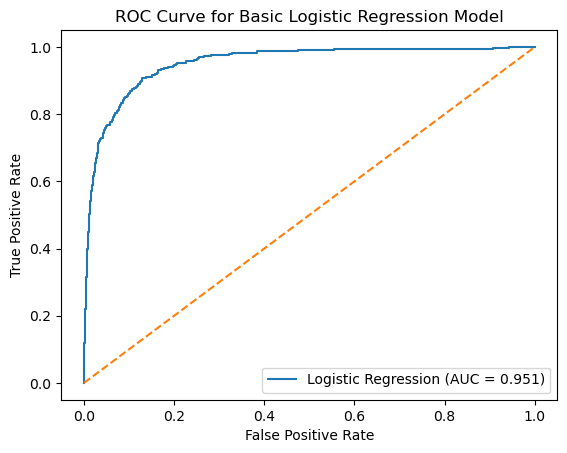

In [ ]:
# Basic Logistic Regression ROC Curve
y_proba_lr = basic_log.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(Y_test, y_proba_lr)
auc_lr = roc_auc_score(Y_test, y_proba_lr)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Basic Logistic Regression Model")
plt.legend()
plt.show()


In [6]:
# Creating undersampled dataset and testing
train_df = X_train.copy()
train_df["TRIPLE-DOUBLE"] = Y_train

df0 = train_df[train_df["TRIPLE-DOUBLE"] == 0]
df1 = train_df[train_df["TRIPLE-DOUBLE"] == 1]

# Undersampling 10 percent of non triple-doubles
df0_small = df0.sample(frac=0.10, random_state=42)

train_small = pd.concat([df0_small, df1]).sample(frac=1, random_state=42)

# Re-separate
X_train_small = train_small.drop("TRIPLE-DOUBLE", axis=1)
y_train_small = train_small["TRIPLE-DOUBLE"]


In [23]:
# Cross Validation
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

param_grid = {
    "logreg__C": [0.001, 0.01, 0.1, 1, 10],
    "logreg__class_weight": [None, "balanced"],
    "logreg__penalty": ["l2"]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="precision",
    n_jobs=-1
)

grid.fit(X_train_small, y_train_small)

print("\nBest params:", grid.best_params_)
print("Best precision on undersampled CV:", grid.best_score_)



Best params: {'logreg__C': 0.001, 'logreg__class_weight': None, 'logreg__penalty': 'l2'}
Best precision on undersampled CV: 0.8425069124423963


In [24]:
# Model fitted with cross validation

best_model = grid.best_estimator_
best_model.fit(X_train_small, y_train_small)

y_prob = best_model.predict_proba(X_test)[:, 1]

# Use default threshold
y_pred_default = (y_prob > 0.5).astype(int)

print("Evaluation on Full Test Set (Threshold = 0.5)")
print("-"*70)
print(classification_report(Y_test, y_pred_default))

print("-"*70)
print(confusion_matrix(Y_test, y_pred_default))


Evaluation on Full Test Set (Threshold = 0.5)
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66398
           1       0.28      0.15      0.20       300

    accuracy                           0.99     66698
   macro avg       0.64      0.58      0.60     66698
weighted avg       0.99      0.99      0.99     66698

----------------------------------------------------------------------
[[66281   117]
 [  254    46]]


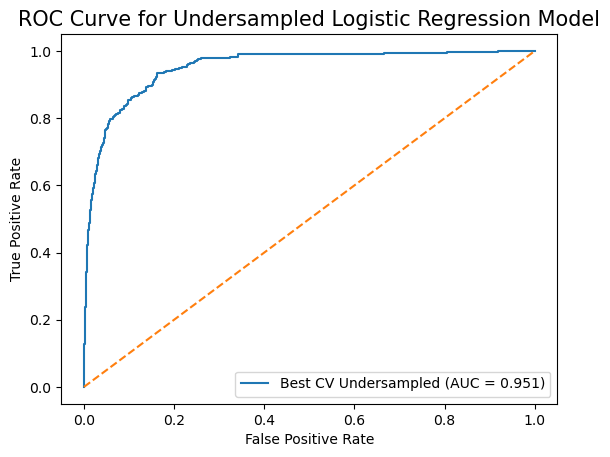

In [29]:
# ROC Curve for Undersampled w/ default threshold
# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(Y_test, y_prob)
auc_score = roc_auc_score(Y_test, y_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f"Best CV Undersampled (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Undersampled Logistic Regression Model", size = 15)
plt.legend()
plt.show()

In [ ]:
# Threshold tuning
thresholds = np.linspace(0, 1, 101)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_prob > t).astype(int)
    f1 = f1_score(Y_test, y_pred_t)
    f1_scores.append(f1)

best_f1_threshold = thresholds[np.argmax(f1_scores)]
best_f1_value = max(f1_scores)

print("Best F1 Threshold:", best_f1_threshold)
print("Best F1 Score:", best_f1_value)



Best F1 Threshold: 0.32
Best F1 Score: 0.2695187165775401


In [ ]:
y_pred_f1 = (y_prob > best_f1_threshold).astype(int)

print("Evaluation at F1-Optimized Threshold")
print("-"*70)
print(classification_report(Y_test, y_pred_f1))

print("Confusion Matrix Results")
print("-"*70)
print(confusion_matrix(Y_test, y_pred_f1))


Evaluation at F1-Optimized Threshold
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     66398
           1       0.20      0.42      0.27       300

    accuracy                           0.99     66698
   macro avg       0.60      0.71      0.63     66698
weighted avg       0.99      0.99      0.99     66698

Confusion Matrix Results
----------------------------------------------------------------------
[[65889   509]
 [  174   126]]


In [ ]:
# XGBoost modeling
boost_model = XGBClassifier(
    objective = "binary:logistic",
    eval_metric = "logloss",
    use_label_encoder = False,
    tree_method = "hist",
    random_state = 42
)

n_neg = (Y_train == 0).sum()
n_pos = (Y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print("scale_pos_weight (original train):", scale_pos_weight)
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3,5,7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "scale_pos_weight": [1, scale_pos_weight]
}

grid_xgb = GridSearchCV(estimator = boost_model, param_grid = param_grid, cv = KFold(n_splits = 6),
                       n_jobs = -1, verbose = 1 )

grid_xgb.fit(X_train_small, y_train_small)

print("Best params: ", grid_xgb.best_params_)
print("Best accuracy: ", grid_xgb.best_score_)

scale_pos_weight (original train): 221.8207126948775
Fitting 6 folds for each of 144 candidates, totalling 864 fits


c:\Users\carlo\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:46:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params:  {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 1, 'subsample': 0.8}
Best accuracy:  0.970121806177343


In [ ]:
# Model using best parameters
best_xgb = grid_xgb.best_estimator_
best_xgb.fit(X_train_small, y_train_small)
y_prob = best_xgb.predict_proba(X_test)[:, 1]
y_pred_default = (y_prob > 0.5).astype(int)

print("XGBoost on Full Test Set(Threshold = 0.5)")
print("-"*70)
print(classification_report(Y_test, y_pred_default))

print("Confusion Matrix")
print("-"*70)
print(confusion_matrix(Y_test, y_pred_default))


print("Accuracy: ", best_xgb.score(X_train_small, y_train_small) )


c:\Users\carlo\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:47:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost on Full Test Set(Threshold = 0.5)
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     66398
           1       0.23      0.40      0.29       300

    accuracy                           0.99     66698
   macro avg       0.61      0.70      0.64     66698
weighted avg       0.99      0.99      0.99     66698

Confusion Matrix
----------------------------------------------------------------------
[[65996   402]
 [  179   121]]
Accuracy:  0.9706023633394179


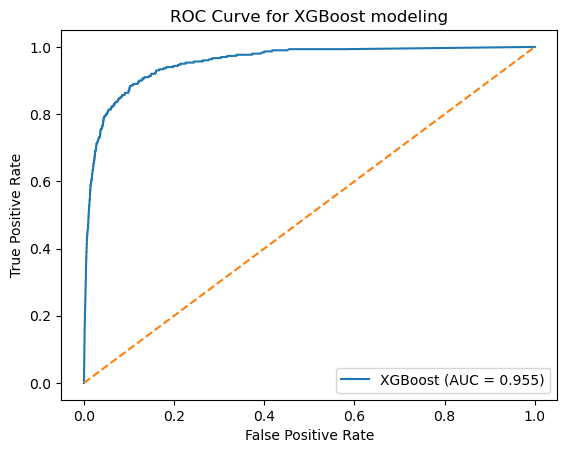

In [ ]:
# ROC Curve for XGBoost model
y_prob = best_xgb.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(Y_test, y_prob)
auc_score = roc_auc_score(Y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for XGBoost modeling")
plt.legend()
plt.show()

# Confusion Matrix Visualized


In [13]:
# Finding optimal thresholding
thresholds = np.linspace(0, 1, 1000)
f1_scores = []

for thres in thresholds:
    y_pred_t = (y_prob > thres).astype(int)
    f1 = f1_score(Y_test, y_pred_t)
    f1_scores.append(f1)

best_thres = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

y_pred_f1 = (y_prob > best_f1_threshold).astype(int)

print("XGBoost using F1-Optimized Threshold ")
print("-"*70)
print(classification_report(Y_test, y_pred_f1))

print("Confusion Matrix")
print("-"*70)
print(confusion_matrix(Y_test, y_pred_f1))

XGBoost using F1-Optimized Threshold 
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     66398
           1       0.14      0.60      0.23       300

    accuracy                           0.98     66698
   macro avg       0.57      0.79      0.61     66698
weighted avg       0.99      0.98      0.99     66698

Confusion Matrix
----------------------------------------------------------------------
[[65303  1095]
 [  120   180]]
